# HSS LLP-jet performance — `hss_stage2_v1` on the 30k test set

Replicates the LLP-only jet analysis from `cocoa_hss_performance.ipynb`, pointed at the
newly-trained stage-2 model's test-set predictions.

- **preds:** full-pipeline inference outputs (`inference_hss_test.yml`) — run that first.
- **truth:** raw ppflow file (has `pflow_*` for the PPflow baseline and `particle_prod_x/y`
  for LLP displacement tagging).
- **LLP tag:** truth particle is LLP-origin if Lxy = sqrt(prod_x^2+prod_y^2) > `llp_lxy_mm`.
  A jet's LLP fraction is the pT-weighted fraction of LLP-origin constituents; `FRAC` is the cut.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
os.environ['PYTHONPATH'] = ':'.join(sys.path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import hgpflow_v2.performance  # don't know why this is needed, but it is
from hgpflow_v2.performance.performance import PerformanceCOCOA
from hgpflow_v2.performance.plot_helper_event import compute_jet_residual_dict, plot_jet_residuals
from hgpflow_v2.performance.llp_helper import (
    tag_truth_jets_llp, select_matched_by_llp, llp_frac_summary,
    llp_efficiency_summary, plot_llp_comparison)

In [3]:
RUN   = '/pscratch/sd/a/agolub/hgpflow_runs/hgpflow_v2/largehsstraining4node25epoch'
TRUTH = '/pscratch/sd/a/agolub/hss_events/HSS_events_with_ppflow/cocoa_hss_pflow_30k.root'

perf = PerformanceCOCOA(
    truth_path=TRUTH,
    pred_path=f'{RUN}/inference/hss_test/pred_*_merged.root',
    ind_threshold=0.4,
    event_number_offset=0,        # splitter -eo for this file (split from event 0)
    llp_lxy_mm=10)                # <-- displacement threshold [mm]

# alignment guard -- expect ~0.9+ (low ~0.2 => wrong truth file or offset)
ts = np.array([x.sum() for x in perf.truth_dict['particle_pt']])
hs = np.array([x.sum() for x in perf.hgpflow_dict['hgpflow_pt']])
print('alignment corr:', np.corrcoef(ts, hs)[0, 1].round(3))

Computing HGPFlow mass...: 100%|██████████| 29976/29976 [00:00<00:00, 43119.86it/s]


E, pT will be scaled by 0.001


Applying fiducial cuts...: 100%|██████████| 30000/30000 [00:00<00:00, 67159.58it/s]
/global/u1/a/agolub/HGPflow/hgpflow_v2/performance/reader.py:196: RuntimeWarning: invalid value encountered in sqrt
  truth_dict['particle_mass'].append(np.sqrt(e**2 - p**2))
/global/u1/a/agolub/HGPflow/hgpflow_v2/performance/reader.py:204: RuntimeWarning: invalid value encountered in sqrt
  truth_dict['pflow_mass'].append(np.sqrt(e**2 - p**2))


common event count: 29976


Filtering and reordering HGPFlow...: 100%|██████████| 12/12 [00:00<00:00, 2661.78it/s]

alignment corr: 0.942


In [4]:
perf.compute_jets(radius=0.4, algo='antikt', store_constituent_idxs=True)  # MUST be True for LLP
perf.match_jets()
tag_truth_jets_llp(perf)   # computes .llp_frac on every truth jet, once
llp_frac_summary(perf)     # distribution + counts, to choose the cut

Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
truth


Computing jets...:   0%|          | 1/29976 [00:00<1:19:16,  6.30it/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


Computing jets...: 100%|██████████| 29976/29976 [01:29<00:00, 333.84it/s]


ppflow


...

Computing jets...: 100%|██████████| 29976/29976 [02:11<00:00, 228.30it/s]


hgpflow


Matching jets...: 100%|██████████| 29976/29976 [00:00<00:00, 50613.43it/s]


tagged 99291 truth jets with .llp_frac (Lxy > 10 mm = LLP-origin)
truth jets: 99291
  llp_frac ~0 (prompt): 18.8%   ~1 (pure LLP): 55.8%
  llp_frac >= 0.10:  79341 jets (79.9%)
  llp_frac >= 0.50:  71124 jets (71.6%)
  llp_frac >= 0.90:  60957 jets (61.4%)


array([0.92446941, 1.        , 1.        , ..., 1.        , 0.        ,
       1.        ], shape=(99291,))

## LLP jet pT residuals (LLP-fraction cut = `FRAC`)

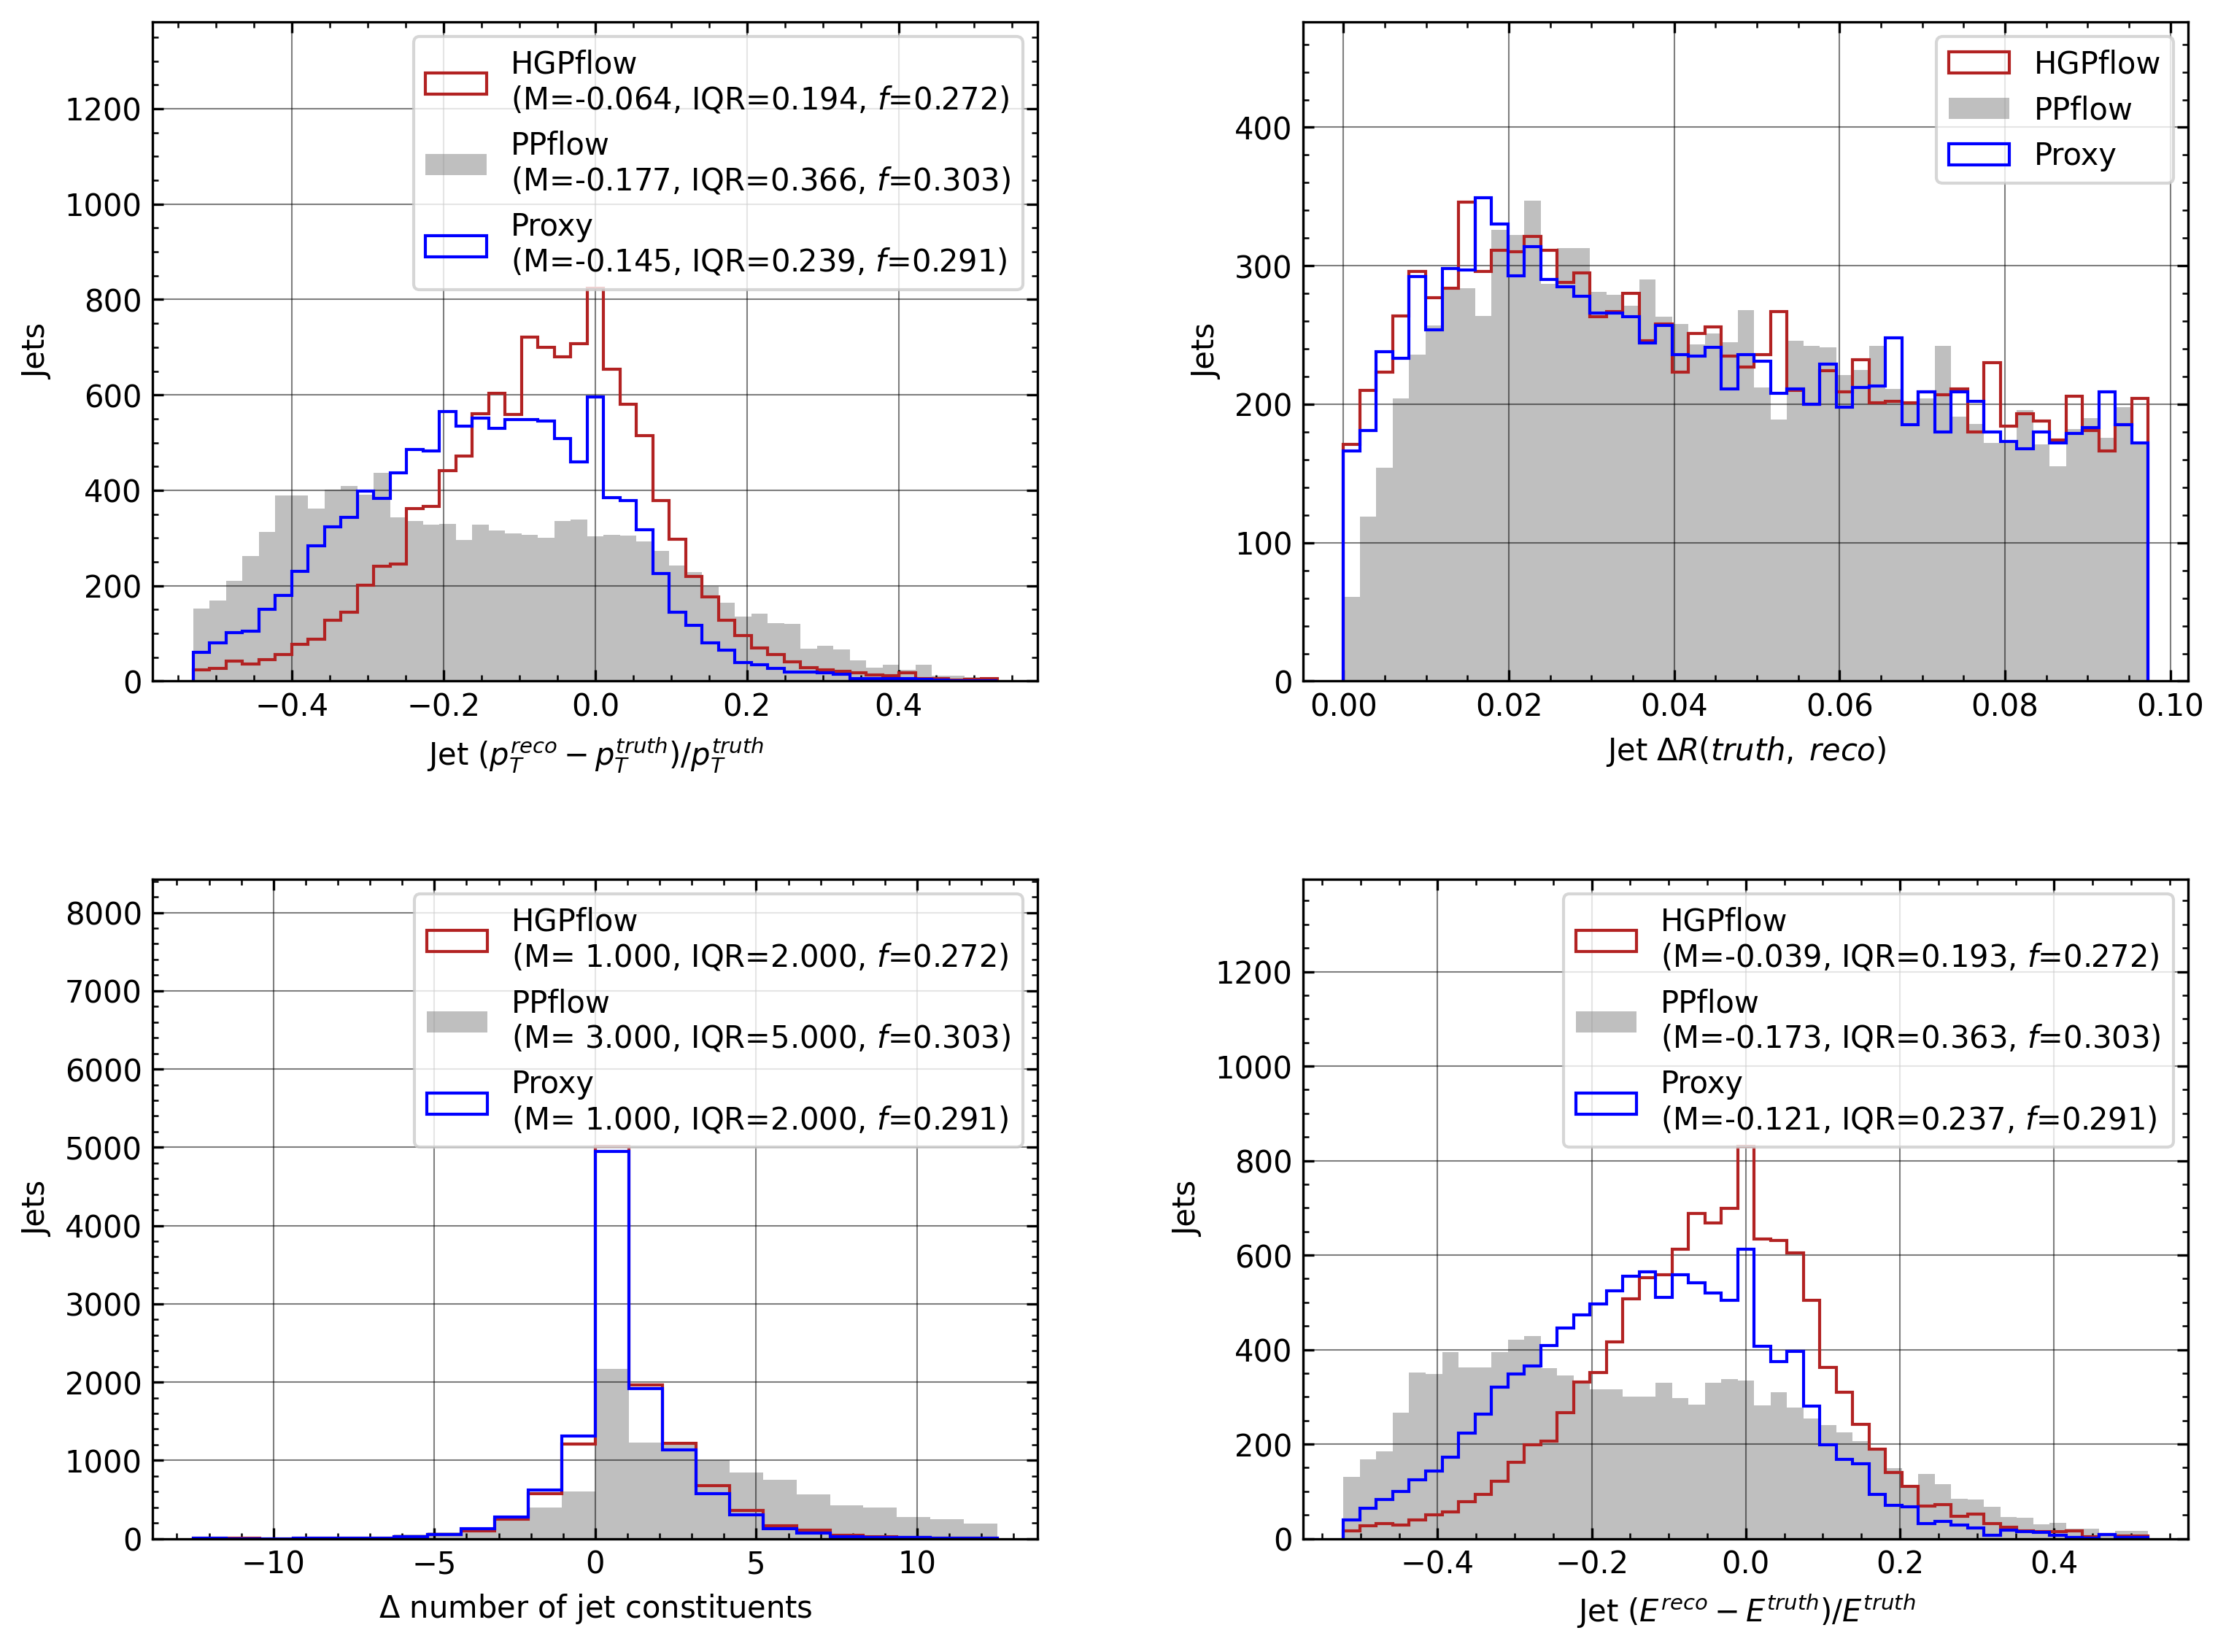

In [5]:
# FRAC is the single knob to scan
FRAC = 0.9
res = compute_jet_residual_dict({
    'hgpflow': select_matched_by_llp(perf.hgpflow_dict['matched_hgpflow_jets'], FRAC, keep='llp'),
    'ppflow' : select_matched_by_llp(perf.truth_dict['matched_ppflow_jets'],   FRAC, keep='llp'),
    'proxy'  : select_matched_by_llp(perf.hgpflow_dict['matched_proxy_jets'],  FRAC, keep='llp'),
})
fig = plot_jet_residuals(res, pt_relative=True)
fig.savefig(f'hss_test_jet_residuals_llp{int(FRAC*100)}.png', dpi=150, bbox_inches='tight')

## Efficiency / residual summary tables (fair matched comparison)

In [6]:
# one-call fair comparison at FRAC=0.9
llp_efficiency_summary(perf, frac=0.9, comp='hgpflow')
# stage-1 proxy, same scoring -> shows what stage 2 adds on LLP jets
llp_efficiency_summary(perf, frac=0.9, comp='proxy')
llp_efficiency_summary(perf, frac=0.9, comp='ppflow')

# scan the LLP-fraction cut
for FRAC in [0.1, 0.5, 0.9]:
    llp_efficiency_summary(perf, frac=FRAC, comp='hgpflow')

--- hgpflow jets | LLP cut llp_frac >= 0.9 | match dr < 0.1 ---
   pT bin |  LLP eff  LLP med  LLP IQR |  prm eff  prm med  prm IQR
  20-30   |   27.5%   -0.065    0.192 |   78.5%   -0.025    0.148
  30-50   |   34.0%   -0.091    0.176 |   84.6%   -0.034    0.135
  50-80   |   43.0%   -0.123    0.163 |   96.8%   -0.045    0.119
  80-150  |   45.5%   -0.133    0.170 |   98.9%   -0.060    0.126
--- proxy jets | LLP cut llp_frac >= 0.9 | match dr < 0.1 ---
   pT bin |  LLP eff  LLP med  LLP IQR |  prm eff  prm med  prm IQR
  20-30   |   28.4%   -0.151    0.248 |   78.8%   -0.077    0.180
  30-50   |   34.5%   -0.189    0.214 |   85.1%   -0.080    0.167
  50-80   |   43.2%   -0.216    0.177 |   97.2%   -0.081    0.141
  80-150  |   46.0%   -0.215    0.163 |   98.9%   -0.080    0.134
--- ppflow jets | LLP cut llp_frac >= 0.9 | match dr < 0.1 ---
   pT bin |  LLP eff  LLP med  LLP IQR |  prm eff  prm med  prm IQR
  20-30   |   28.9%   -0.192    0.381 |   78.7%   -0.011    0.242
  30-50   |  

## Efficiency & residual vs jet pT: LLP vs prompt jets

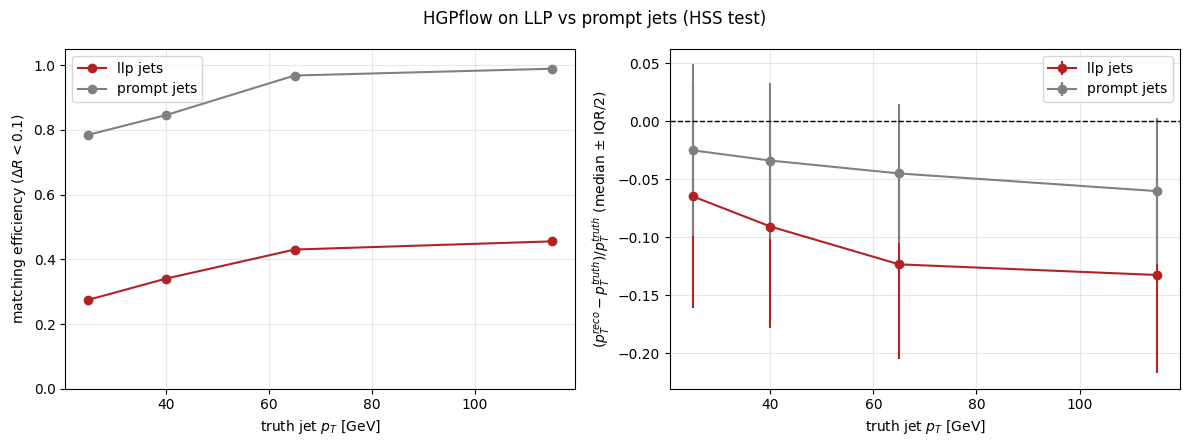

In [7]:
def llp_binned_arrays(perf, frac=0.9, comp='hgpflow', dr_cut=0.1,
                      pt_bins=np.array([20,30,50,80,150]), eta_max=2.5):
    key = {'hgpflow':'matched_hgpflow_jets','proxy':'matched_proxy_jets'}[comp]
    matched = perf.hgpflow_dict[key]
    centers = 0.5*(pt_bins[:-1]+pt_bins[1:])
    out = {}
    for keep in ('llp','prompt'):
        ref_ev, comp_ev = select_matched_by_llp(matched, frac, keep=keep)
        rpt  = np.array([r.pt for refs in ref_ev for r in refs])
        reta = np.array([abs(r.eta) for refs in ref_ev for r in refs])
        dR   = np.array([r.delta_R(c) for refs,comps in zip(ref_ev,comp_ev) for r,c in zip(refs,comps)])
        rel  = np.array([(c.pt-r.pt)/r.pt for refs,comps in zip(ref_ev,comp_ev) for r,c in zip(refs,comps)])
        fid  = reta < eta_max
        eff, med, iqr = [], [], []
        for lo,hi in zip(pt_bins[:-1], pt_bins[1:]):
            b = fid & (rpt>=lo) & (rpt<hi)
            m = b & (dR < dr_cut)
            eff.append(m.sum()/b.sum() if b.sum() else np.nan)
            med.append(np.median(rel[m]) if m.sum() else np.nan)
            iqr.append((np.percentile(rel[m],75)-np.percentile(rel[m],25)) if m.sum() else np.nan)
        out[keep] = dict(centers=centers, eff=np.array(eff), med=np.array(med), iqr=np.array(iqr))
    return out

d = llp_binned_arrays(perf, frac=0.9)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12,4.5))
for keep, c in [('llp','firebrick'), ('prompt','gray')]:
    a1.plot(d[keep]['centers'], d[keep]['eff'], 'o-', color=c, label=f'{keep} jets')
    a2.errorbar(d[keep]['centers'], d[keep]['med'], yerr=d[keep]['iqr']/2, fmt='o-', color=c, label=f'{keep} jets')
a1.set(xlabel='truth jet $p_T$ [GeV]', ylabel='matching efficiency ($\\Delta R<0.1$)', ylim=(0,1.05)); a1.legend(); a1.grid(alpha=.3)
a2.axhline(0, ls='--', c='k', lw=1)
a2.set(xlabel='truth jet $p_T$ [GeV]', ylabel='$(p_T^{reco}-p_T^{truth})/p_T^{truth}$ (median $\\pm$ IQR/2)'); a2.legend(); a2.grid(alpha=.3)
fig.suptitle('HGPflow on LLP vs prompt jets (HSS test)'); fig.tight_layout()
fig.savefig('hss_test_llp_vs_prompt_vs_pt.png', dpi=150, bbox_inches='tight')

## Combined LLP comparison figure (hgpflow / proxy / ppflow)

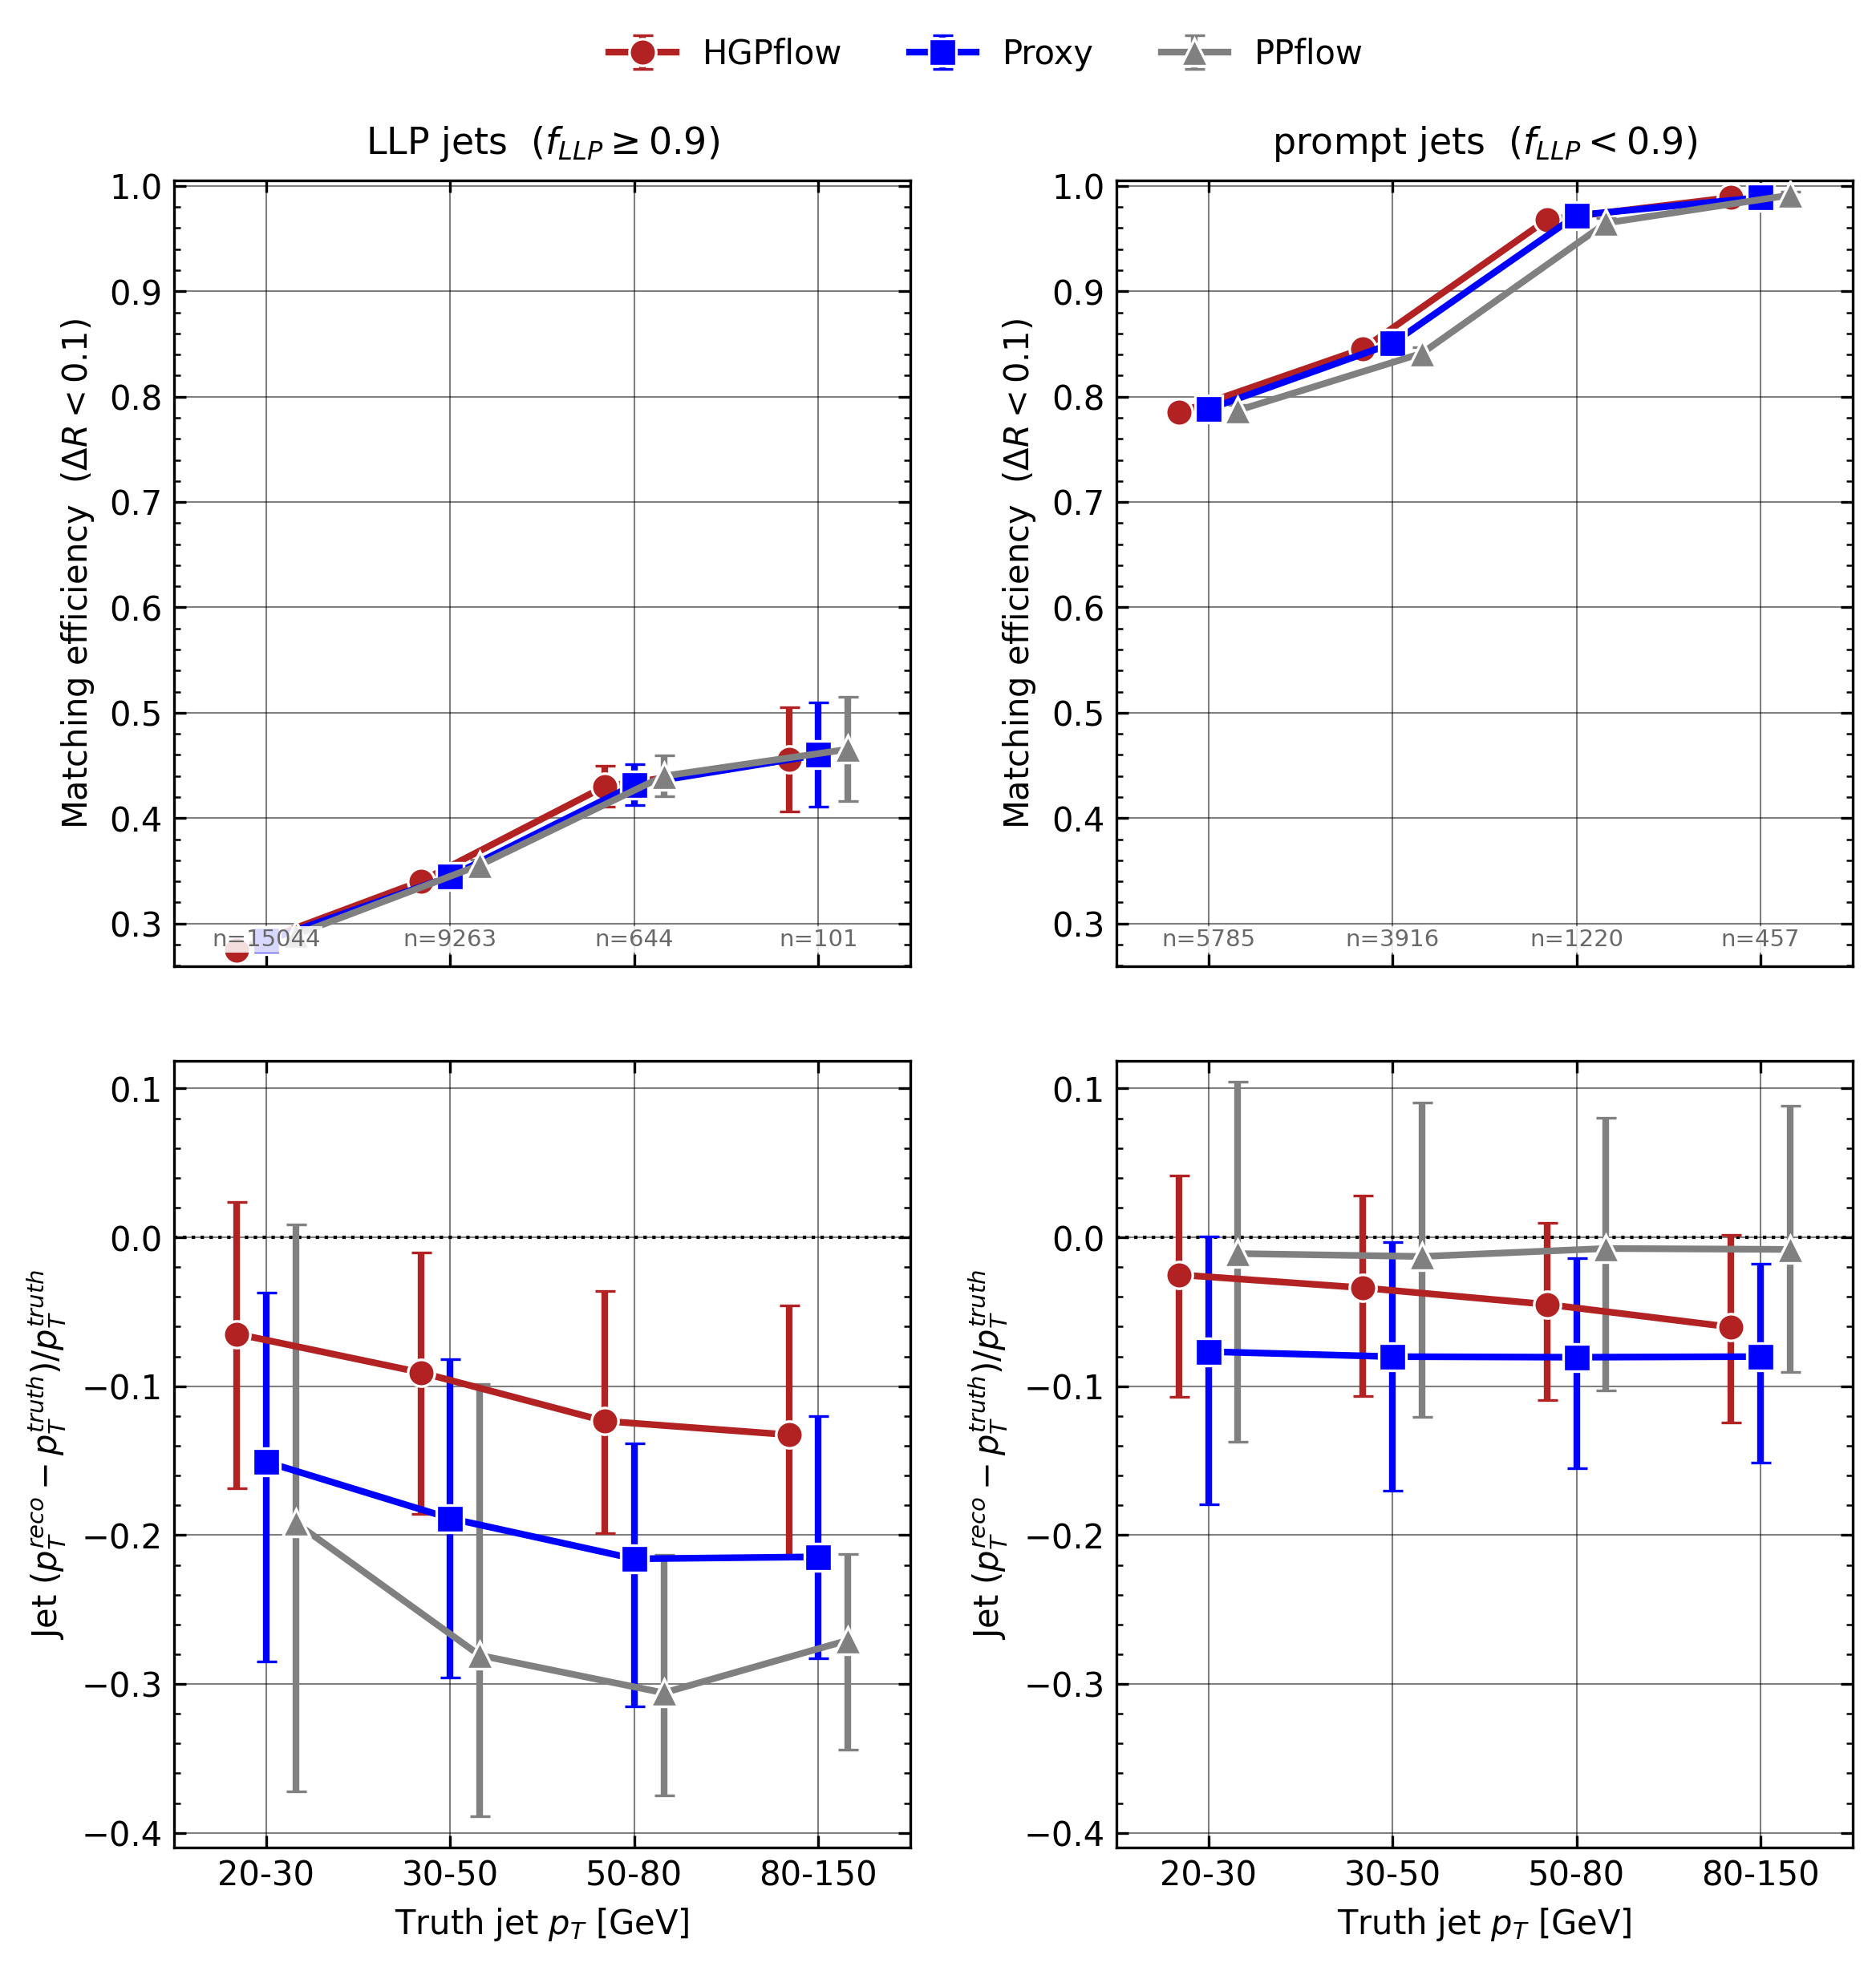

In [8]:
fig, summaries = plot_llp_comparison(perf, frac=0.9)